# Entrega Sprint — Semana 6: A/B criticidad (play / pausa / stop)

Notebook principal de la slide **Entrega sprint semana 6**.

| Sección | Contenido |
|---------|----------|
| 1 | Contexto y línea base |
| 2 | Experimentos A/B (≤3 variantes ML + referencia léxica) |
| 3 | Tabla comparable (holdout + GroupKFold) |
| 4 | Gráfico F1 por clase (baseline vs ganadora) |
| 5 | Validación, decisión y reproducibilidad |
| 6 | Riesgos y próximos pasos |

**Cwd:** `tesis2` o `tesis2/notebooks`. **Sin API** en el núcleo (coste 0).

Relacionado: `variables_modulo_criticidad.ipynb`, `eval_early_gate_vs_gold.ipynb` (LLM, opcional).

## 1. Contexto y línea base

**Objetivo del módulo:** clasificar la **política operativa** `gold_mode` ∈ {`play`, `pausa`, `stop`} a partir del texto del requerimiento (`requirement`), antes del Arquitecto/Sentinel.

- **Dataset:** `data/criticidad_cases/casos_gold_criticidad_v2.jsonl` (300 casos).
- **Métricas centrales:** **F1-macro** (multiclase balanceada) y **Cohen κ** (acuerdo ordinal nominal).
- **Baseline (semana 5, repo padre):** TF-IDF *word* (1,1) + `LogisticRegression`, sin LLM — `scripts/run_week5_experiments.py`.
- **EarlyGate (referencia):** gate temprano en `agentes/core/early_gate.py`; con LLM ~acc 0.79, κ 0.69 (confusión **pausa→play**). Este notebook **no** llama al LLM por defecto.

In [1]:
%matplotlib inline

import json
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_scripts_dir() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        cand = p / "scripts" / "run_week6_experiments.py"
        if cand.is_file():
            return p / "scripts"
    raise FileNotFoundError("No se encontró scripts/run_week6_experiments.py")


sys.path.insert(0, str(find_scripts_dir()))

import run_week6_experiments as w6


def find_tesis2_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "agentes" / "core" / "early_gate.py").is_file():
            return p
    raise FileNotFoundError(
        "No se encontró tesis2: cwd debe ser `tesis2` o un subdirectorio."
    )


TESIS2_ROOT = find_tesis2_root()
OUT_DIR = TESIS2_ROOT / "docs" / "experiments" / "week6"
CORPUS = TESIS2_ROOT / "data" / "criticidad_cases" / "casos_gold_criticidad_v2.jsonl"
SEED = 42
TEST_SIZE = 0.2
GROUP_K = 5

print("TESIS2_ROOT =", TESIS2_ROOT)
print("Corpus:", CORPUS, "→", CORPUS.is_file())

TESIS2_ROOT = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2
Corpus: /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/data/criticidad_cases/casos_gold_criticidad_v2.jsonl → True


## 2. Experimentos A/B (un cambio por variante)

| Variante | Cambio respecto al baseline |
|----------|----------------------------|
| **baseline** | TF-IDF *word* (1,1) + LogReg |
| **var1** | Solo n-gramas *word* (1,2) |
| **var2** | Solo TF-IDF *char* (3,5) |
| **early_lexical** | Reglas `EarlyGate.lexical_classify` (coste API 0) |

Clasificador común (ML): `solver=lbfgs`, `max_iter=2000`, `random_state=42`.

In [2]:
df = w6.load_jsonl(CORPUS)
X = df["requirement"].astype(str).to_numpy()
y = df["gold_mode"].astype(str).to_numpy()
groups = df["template_index"].fillna(-1).astype(int).to_numpy()

import importlib.util

eg_path = TESIS2_ROOT / "agentes" / "core" / "early_gate.py"
spec = importlib.util.spec_from_file_location("early_gate_standalone", eg_path)
eg_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eg_mod)
gate = eg_mod.EarlyGate()
lexical_predict = lambda t: gate.lexical_classify(t)[0]

experiments = w6.build_experiments(SEED)
rows = []
holdout_preds = {}

for cfg in experiments:
    if cfg.kind == "sklearn":
        pipe = w6.make_pipeline(cfg)
        hold, y_te, y_pr = w6.eval_holdout_sklearn(pipe, X, y, test_size=TEST_SIZE, seed=SEED)
        gcv = w6.eval_groupkfold_sklearn(
            lambda c=cfg: w6.make_pipeline(c), X, y, groups, n_splits=GROUP_K
        )
    else:
        hold, y_te, y_pr = w6.eval_holdout_lexical(X, y, lexical_predict, test_size=TEST_SIZE, seed=SEED)
        gcv = w6.eval_groupkfold_lexical(X, y, groups, lexical_predict, n_splits=GROUP_K)
    holdout_preds[cfg.name] = (y_te, y_pr)
    rows.append(
        {
            "Variante": cfg.name,
            "F1-macro (holdout)": round(hold["f1_macro"], 4),
            "F1-macro (GroupKFold)": f"{gcv['f1_macro_mean']:.4f} ± {gcv['f1_macro_std']:.4f}",
            "Accuracy": round(hold["accuracy"], 4),
            "κ": round(hold["kappa"], 4),
            "Coste/latencia": w6.cost_label(cfg.name, hold["elapsed_sec"]),
        }
    )

tabla = pd.DataFrame(rows).sort_values("Variante")
tabla

,Variante,F1-macro (holdout),F1-macro (GroupKFold),Accuracy,κ,Coste/latencia
0,baseline,1.0000,0.9866 ± 0.0165,1.0000,1.00,API 0 · ~0.02s holdout (sklearn)
3,early_lexical,0.7693,0.7180 ± 0.1655,0.7667,0.65,API 0 · ~0.01s holdout (reglas)
1,var1,1.0000,0.9899 ± 0.0201,1.0000,1.00,API 0 · ~0.04s holdout (sklearn)
2,var2,1.0000,1.0000 ± 0.0000,1.0000,1.00,API 0 · ~1.28s holdout (sklearn)


## 3. Tabla comparable y artefactos

Validación dual: **holdout estratificado** (`test_size=0.2`, `seed=42`) y **GroupKFold(k=5)** agrupando por `template_index`.

Artefactos: /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/docs/experiments/week6
Variante recomendada (GKF): var2


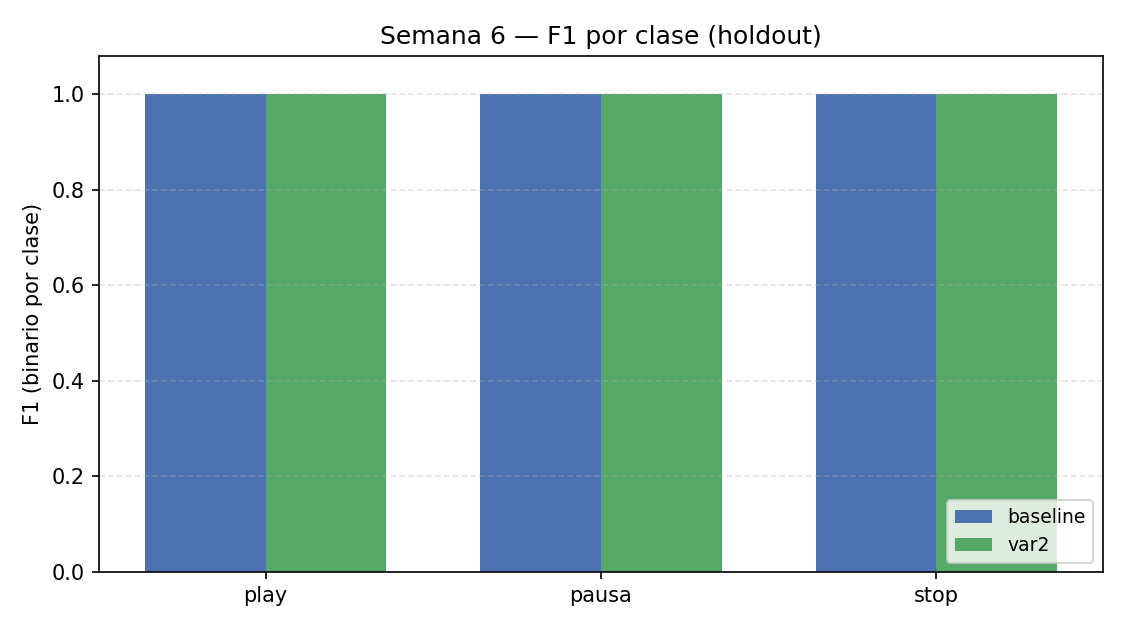

In [3]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
run_id = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

# Persistencia (misma convención que el script)
df_export = pd.DataFrame(rows)
df_export.to_csv(OUT_DIR / "results.csv", index=False)

ml = tabla[tabla["Variante"].isin(["baseline", "var1", "var2"])].copy()
ml["gkf_val"] = ml["F1-macro (GroupKFold)"].str.split().str[0].astype(float)
best_name = ml.loc[ml["gkf_val"].idxmax(), "Variante"]

y_te_b, y_pr_b = holdout_preds["baseline"]
y_te_w, y_pr_w = holdout_preds[best_name]
f1_baseline = w6.f1_per_class(y_te_b, y_pr_b)
f1_best = w6.f1_per_class(y_te_w, y_pr_w)

fig_path = OUT_DIR / "f1_por_clase_baseline_vs_mejor.png"
w6.plot_f1_per_class(f1_baseline, f1_best, best_name, fig_path)

summary = {
    "run_id": run_id,
    "variante_recomendada": best_name,
    "razon": "Mayor F1-macro en GroupKFold por plantilla; despliegue sin API.",
    "f1_por_clase_holdout": {"baseline": f1_baseline, best_name: f1_best},
    "tabla": rows,
}
(OUT_DIR / "summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print("Artefactos:", OUT_DIR)
print("Variante recomendada (GKF):", best_name)
display(Image(filename=str(fig_path)))

## 4. Gráfico representativo

F1 binario por clase en **holdout** (misma partición `seed=42`): compara **baseline** vs la variante ML con mejor F1-macro en GroupKFold (anti-leakage por plantilla).

## 5. Validación y decisión

- **Split principal para decisión:** `GroupKFold(n_splits=5)` con `groups=template_index` — evita que la misma plantilla aparezca en train y test (fuga estructural).
- **Holdout:** complemento rápido; puede sobreestimar si el test es pequeño y el problema es separable.
- **Features:** únicamente texto `requirement`. **No** se usan `tags`, `id`, `template_index` ni metadatos como entrada del modelo.
- **Pipeline sklearn:** `TfidfVectorizer` dentro de `Pipeline` → `fit` solo en train de cada split.

**Decisión (plantilla):** adoptar la variante ML con mayor **F1-macro (GroupKFold)** si la ganancia justifica el coste; en empate, preferir **baseline** (menor complejidad). **EarlyGate léxico** queda como referencia de coste cero pero suele quedar por debajo del TF-IDF en F1/κ. **EarlyGate + LLM** no sustituye al baseline ML en coste/latencia para despliegue masivo; calibrar aparte (`eval_early_gate_vs_gold.ipynb`).

In [4]:
print(f"→ Adoptar: **{best_name}** (criterio: F1-macro GKF, κ holdout en tabla).")
print("F1 por clase holdout — baseline:", f1_baseline)
print(f"F1 por clase holdout — {best_name}:", f1_best)

→ Adoptar: **var2** (criterio: F1-macro GKF, κ holdout en tabla).
F1 por clase holdout — baseline: {'play': 1.0, 'pausa': 1.0, 'stop': 1.0}
F1 por clase holdout — var2: {'play': 1.0, 'pausa': 1.0, 'stop': 1.0}


## 6. Reproducibilidad

```bash
# Desde tesis2/ (venv con sklearn, pandas, matplotlib)
python scripts/run_week6_experiments.py
python scripts/run_week6_experiments.py --copy-to-reports

# Baseline histórico (repo padre)
cd .. && python scripts/run_week5_experiments.py

# Este notebook
jupyter notebook notebooks/semana6_entrega_criticidad_ab.ipynb
```

Salida fija: `docs/experiments/week6/{results.csv, summary.json, f1_por_clase_baseline_vs_mejor.png}`.
Copia opcional: `reports/week6_<timestamp>/`.

## 7. Riesgos y próximos pasos

- **Recall bajo en `pausa`:** tanto ML como EarlyGate confunden `pausa` con `play`; priorizar más ejemplos `pausa` o umbrales léxicos.
- **Drift / calibración EarlyGate:** re-evaluar κ y matriz de confusión al cambiar dominio (nuevas plantillas o vocabulario); el gate LLM requiere `DEEPSEEK_API_KEY` y control de coste.

**Próximo sprint:** integrar la variante elegida como fallback barato en pipeline; Sentinel sigue en capa blueprint.

### Opcional — EarlyGate con LLM (OFF por defecto)

Requiere `DEEPSEEK_API_KEY`. Costoso (~300 llamadas). Usar solo para comparación puntual.

In [5]:
RUN_EARLY_LLM = False  # ← cambiar a True solo con API y presupuesto

if RUN_EARLY_LLM:
    import os
    from dotenv import load_dotenv
    from sklearn.metrics import cohen_kappa_score, f1_score

    load_dotenv(TESIS2_ROOT / ".env")
    if not os.getenv("DEEPSEEK_API_KEY", "").strip():
        raise RuntimeError("Defina DEEPSEEK_API_KEY en tesis2/.env")
    preds = []
    for req in X[:20]:  # submuestra de prueba
        d = gate.decide(str(req))
        preds.append(d.get("gold_mode") or d.get("mode") or "play")
    print(
        "Submuestra n=20 — acc:",
        (np.array(preds) == y[:20]).mean(),
        "κ:",
        cohen_kappa_score(y[:20], preds, labels=w6.LABELS),
    )
else:
    print("EarlyGate LLM desactivado (RUN_EARLY_LLM=False). Ver eval_early_gate_vs_gold.ipynb.")

EarlyGate LLM desactivado (RUN_EARLY_LLM=False). Ver eval_early_gate_vs_gold.ipynb.
